<a href="https://colab.research.google.com/github/Magdyibrahim112/MNIST-MLP--neural_network_project-/blob/main/Neural_Network_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Neural** **Networks** **Project**

Library

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


Device

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Data

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128
)

Model MLP

In [21]:
class MLP(nn.Module):

    def __init__(self, activation="relu"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()

        elif activation == "tanh":
            act = nn.Tanh()

        else:
            act = nn.ReLU()

        self.model = nn.Sequential(

            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            act,
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            act,
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.model(x)

Train Function

In [22]:
def train(model, train_loader, val_loader,
          epochs=10, lr=0.001):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        # ======================
        # TRAIN
        # ======================

        model.train()

        total = 0
        correct = 0
        running_loss = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            loss = criterion(out, y)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, pred = torch.max(out, 1)

            total += y.size(0)

            correct += (pred == y).sum().item()

        train_loss = running_loss / len(train_loader)

        train_acc = correct / total

        # ======================
        # VALIDATION
        # ======================

        model.eval()

        total = 0
        correct = 0
        val_loss = 0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device)

                out = model(x)

                loss = criterion(out, y)

                val_loss += loss.item()

                _, pred = torch.max(out, 1)

                total += y.size(0)

                correct += (pred == y).sum().item()

        val_loss /= len(val_loader)

        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(

            f"Epoch {epoch+1}: "

            f"Train Loss {train_loss:.4f}, "

            f"Train Acc {train_acc:.4f}, "

            f"Val Loss {val_loss:.4f}, "

            f"Val Acc {val_acc:.4f}"
        )

    return (

        train_losses,

        val_losses,

        train_accs,

        val_accs
    )

Experiments

In [23]:
experiments = {

    "ReLU": "relu",

    "Tanh": "tanh"
}

results = {}

for name, act in experiments.items():

    print("\n==============================")

    print("Experiment:", name)

    print("==============================")

    model = MLP(act).to(device)

    train_losses, val_losses, train_accs, val_accs = train(

        model,

        train_loader,

        val_loader
    )

    results[name] = {

        "model": model,

        "train_losses": train_losses,

        "val_losses": val_losses,

        "train_accs": train_accs,

        "val_accs": val_accs,

        "best_acc": max(val_accs)
    }


Experiment: ReLU
Epoch 1: Train Loss 0.3590, Train Acc 0.9049, Val Loss 0.1484, Val Acc 0.9573
Epoch 2: Train Loss 0.1600, Train Acc 0.9529, Val Loss 0.1011, Val Acc 0.9677
Epoch 3: Train Loss 0.1224, Train Acc 0.9628, Val Loss 0.0918, Val Acc 0.9711
Epoch 4: Train Loss 0.1000, Train Acc 0.9691, Val Loss 0.0979, Val Acc 0.9693
Epoch 5: Train Loss 0.0873, Train Acc 0.9721, Val Loss 0.0753, Val Acc 0.9756
Epoch 6: Train Loss 0.0775, Train Acc 0.9753, Val Loss 0.0785, Val Acc 0.9772
Epoch 7: Train Loss 0.0710, Train Acc 0.9774, Val Loss 0.0729, Val Acc 0.9777
Epoch 8: Train Loss 0.0654, Train Acc 0.9791, Val Loss 0.0740, Val Acc 0.9769
Epoch 9: Train Loss 0.0610, Train Acc 0.9808, Val Loss 0.0687, Val Acc 0.9785
Epoch 10: Train Loss 0.0580, Train Acc 0.9811, Val Loss 0.0716, Val Acc 0.9782

Experiment: Tanh
Epoch 1: Train Loss 0.3819, Train Acc 0.8942, Val Loss 0.2261, Val Acc 0.9323
Epoch 2: Train Loss 0.2287, Train Acc 0.9327, Val Loss 0.1878, Val Acc 0.9413
Epoch 3: Train Loss 0.1860,

Best Model

In [24]:
best_name = max(

    results,

    key=lambda x: results[x]["best_acc"]
)

model = results[best_name]["model"]

print("\nBEST MODEL:", best_name)
print(f"BEST VALIDATION ACCURACY: {best_acc:.3f}%")


BEST MODEL: ReLU
BEST VALIDATION ACCURACY: 97.792%


Test Evaluation

In [25]:
model.eval()

y_true = []

y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        out = model(x)

        pred = torch.argmax(out, 1)

        y_true.extend(y.numpy())

        y_pred.extend(pred.cpu().numpy())

acc = np.mean(

    np.array(y_true) == np.array(y_pred)
)

print("\nTest Accuracy:", acc)


Test Accuracy: 0.9808


Loss curves

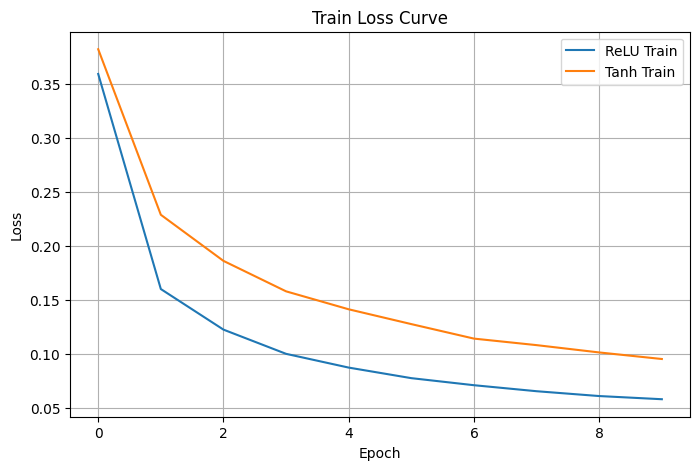

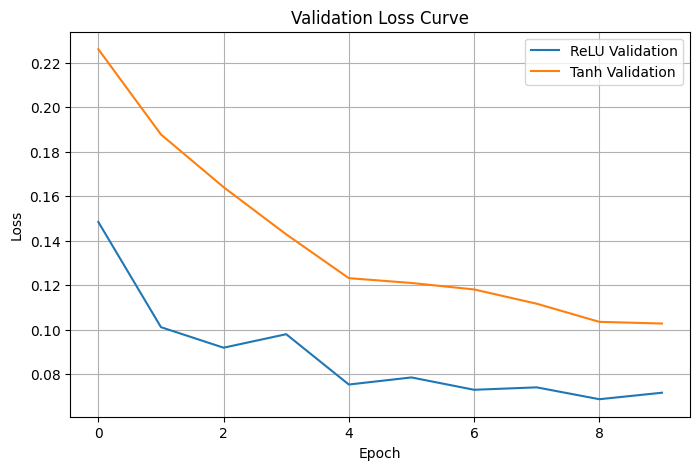

In [35]:
# =================
# Train Loss Curve
# =================
plt.figure(figsize=(8,5))

for name in results:

    plt.plot(
        results[name]["train_losses"],
        label=f"{name} Train"
    )

plt.title("Train Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("results/train_loss.png")
# ======================
# Validation Loss Curve
# ======================
plt.figure(figsize=(8,5))

for name in results:

    plt.plot(
        results[name]["val_losses"],
        label=f"{name} Validation"
    )

plt.title("Validation Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("results/val_loss.png")

Accuracy curves

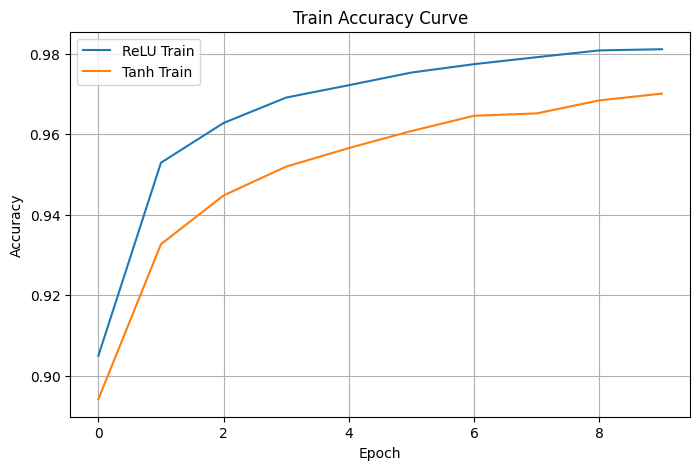

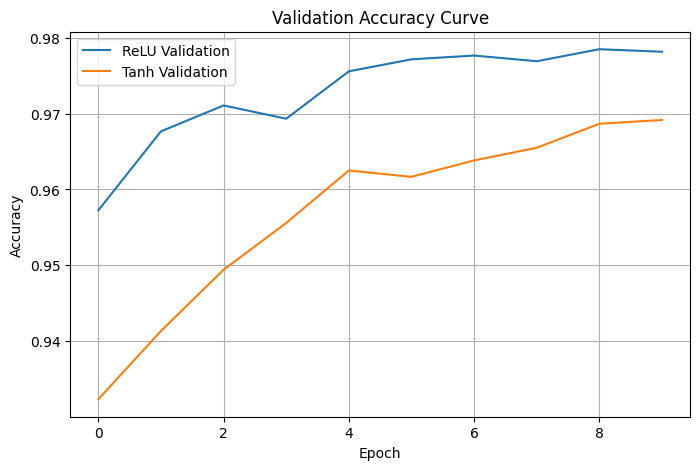

In [36]:

# ======================
# Train Accuracy Curve
# ======================
plt.figure(figsize=(8,5))

for name in results:

    plt.plot(
        results[name]["train_accs"],
        label=f"{name} Train"
    )

plt.title("Train Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("results/train_acc.png")

# =========================
# Validation Accuracy Curve
# =========================
plt.figure(figsize=(8,5))

for name in results:

    plt.plot(
        results[name]["val_accs"],
        label=f"{name} Validation"
    )

plt.title("Validation Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("results/val_acc.png")

In [28]:
# ======================
# Comparison Table
# ======================

print("\n===================================================")
print(f"{'Model':<10} {'Best Val Acc':<20} {'Test Acc':<15}")
print("===================================================")

for name in results:

    best_val_acc = results[name]["best_acc"] * 100

    # استخدام نفس الموديل للاختبار
    model = results[name]["model"]

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)

            out = model(x)

            pred = torch.argmax(out, 1)

            y_true.extend(y.numpy())

            y_pred.extend(pred.cpu().numpy())

    test_acc = np.mean(
        np.array(y_true) == np.array(y_pred)
    ) * 100

    print(f"{name:<10} {best_val_acc:<20.2f} {test_acc:<15.2f}")

print("===================================================")


Model      Best Val Acc         Test Acc       
ReLU       97.85                98.08          
Tanh       96.92                97.01          


In [29]:
%%writefile main.py

Writing main.py


In [31]:
%%writefile requirements.txt
torch
torchvision
matplotlib
numpy
scikit-learn

Overwriting requirements.txt


In [32]:
%%writefile README.md
# MNIST Handwritten Digit Classification using MLP

## Problem Description
This project implements an MLP for MNIST classification.

## Dataset
https://yann.lecun.com/exdb/mnist/

## How to Run
pip install -r requirements.txt
python main.py

Writing README.md


In [33]:
!mkdir results

In [37]:
from google.colab import files
files.download("main.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>